In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../datasets.csv')

df['Declaration Date'] = pd.to_datetime(df['Declaration Date'], format='%m/%d/%Y')

df['year'] = df['Declaration Date'].dt.year
df['month'] = df['Declaration Date'].dt.month

print(df['Declaration Date'].isna().sum(), "missing dates found.")
yearly_counts = df.groupby('year').size()

type_trends = df.groupby(['year', 'Disaster Type']).size().unstack(fill_value=0)

0 missing dates found.


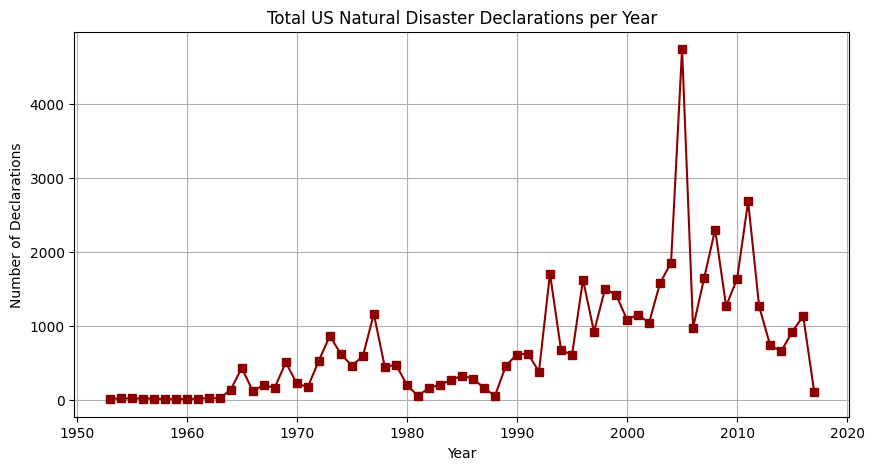

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(yearly_counts.index, yearly_counts.values, marker='s', color='darkred')
plt.title('Total US Natural Disaster Declarations per Year')
plt.xlabel('Year')
plt.ylabel('Number of Declarations')
plt.grid(True)
plt.show()

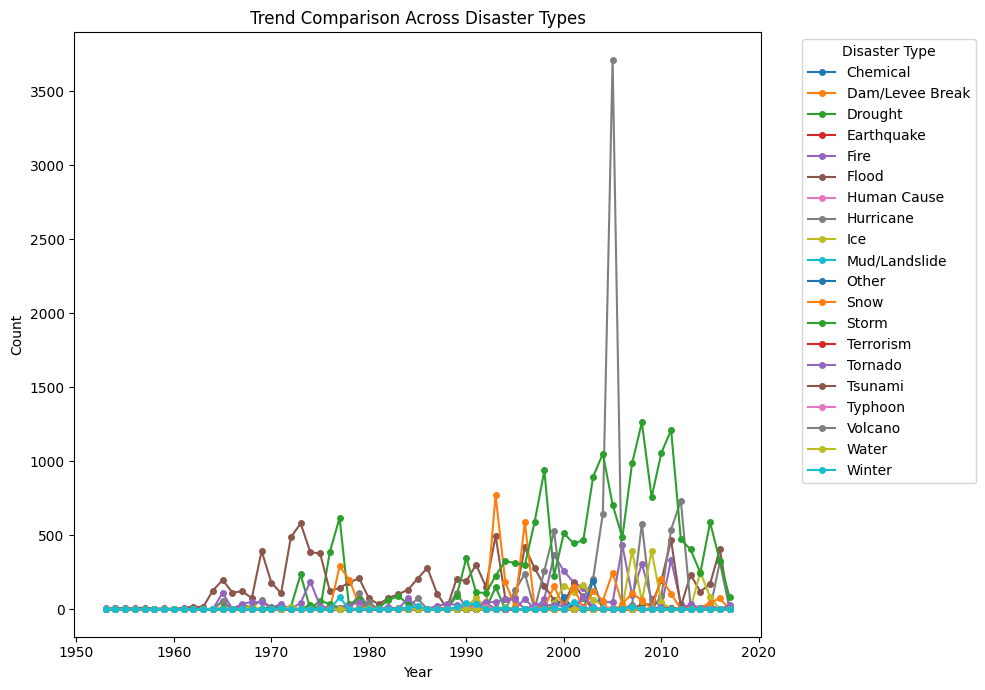

In [13]:
type_trends.plot(figsize=(10, 7), marker='o', markersize=4)
plt.title('Trend Comparison Across Disaster Types')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Disaster Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

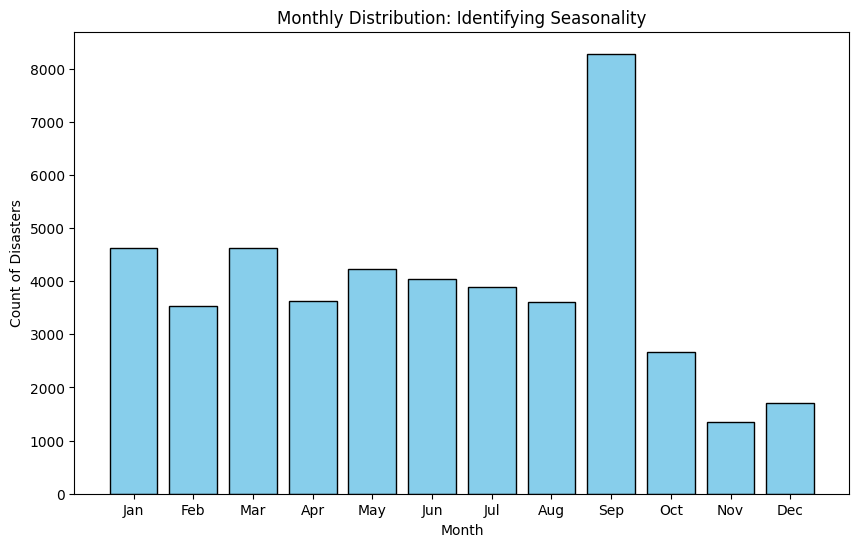

In [14]:
monthly_counts = df.groupby('month').size()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 6))
plt.bar(month_labels, monthly_counts.values , color='skyblue' , edgecolor='black')
plt.title('Monthly Distribution: Identifying Seasonality')
plt.xlabel('Month')
plt.ylabel('Count of Disasters')
plt.show()

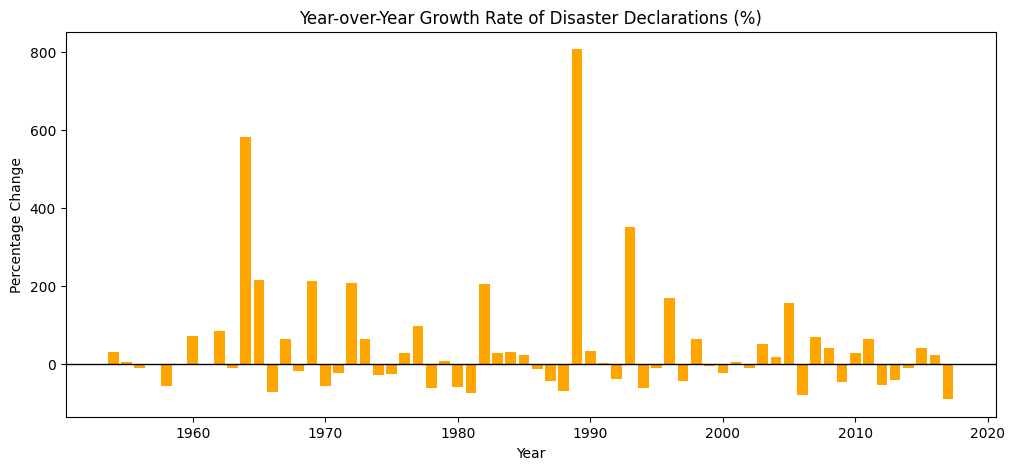

In [16]:
growth_rate = yearly_counts.pct_change() * 100

plt.figure(figsize=(12, 5))
plt.bar(growth_rate.index, growth_rate.values, color='orange')
plt.title('Year-over-Year Growth Rate of Disaster Declarations (%)')
plt.xlabel('Year')
plt.ylabel('Percentage Change')
plt.axhline(0, color='black', lw=1)
plt.show()